# Notebook 11 — EDA Visualization
### Sprint 4 | Data Inspection & Exploratory Data Analysis (EDA)

**Structure for every visualization below:** Why this visualization was selected →
Generate it → Interpret it → State the insight obtained.

**Dataset:** Telco Customer Churn (7,043 customers, 21 columns), with `TotalCharges`
corrected to numeric.

**A deliberate note on approach:** several chart *types* required by this notebook
(histogram, box plot, scatter plot, pair plot, heatmap) already appeared in Notebooks
4-10. Repeating the exact same charts here would violate this notebook's explicit
instruction not to create graphs "simply for the sake of creating graphs." Instead, every
visualization below asks a **new question** not yet answered in this sprint, even where
the chart type has been used before.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 4.5)

df = pd.read_csv("telco_churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"Dataset ready: {df.shape[0]:,} rows, {df.shape[1]} columns")


Dataset ready: 7,043 rows, 21 columns


---
## 1. Histogram — Does a Log Transform Actually Fix `TotalCharges`'s Skew?

### Why This Visualization Was Selected
Notebook 8 recommended a log-transformation for `TotalCharges` based on its skewness
number alone. A histogram is the right tool to visually verify that recommendation
actually works, rather than trusting the skewness statistic in isolation — exactly the
"always visualize, don't just summarize" lesson from Notebook 8 applied to a new question.

### Implementation


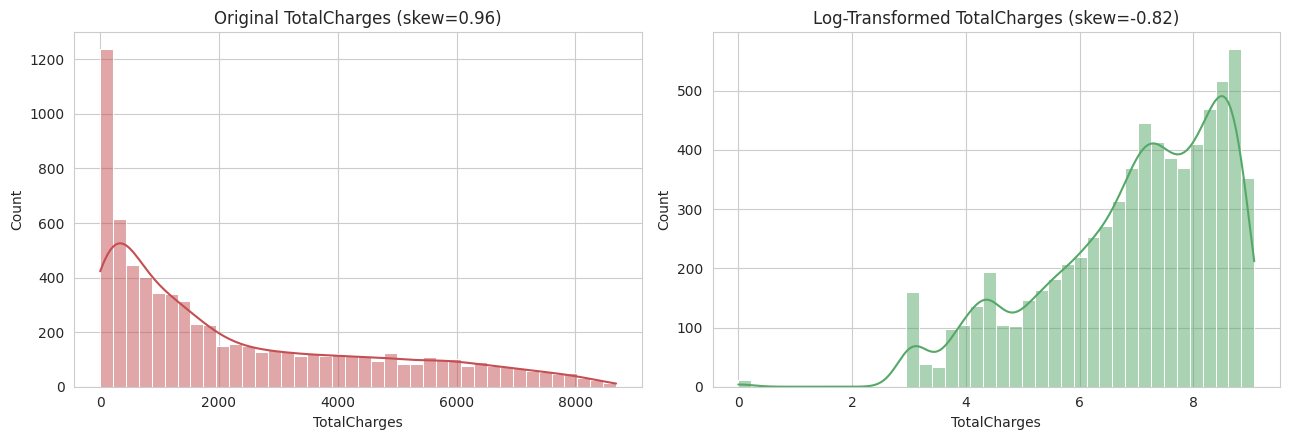

In [2]:
from scipy import stats

log_total_charges = np.log1p(df['TotalCharges'])   # log1p handles the 11 zero-charge customers safely

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['TotalCharges'], bins=40, kde=True, ax=axes[0], color='#C44E52')
axes[0].set_title(f"Original TotalCharges (skew={stats.skew(df['TotalCharges']):.2f})")

sns.histplot(log_total_charges, bins=40, kde=True, ax=axes[1], color='#55A868')
axes[1].set_title(f"Log-Transformed TotalCharges (skew={stats.skew(log_total_charges):.2f})")

plt.tight_layout()
plt.show()


### Interpretation
The log transform doesn't simply "fix" the skew to near zero — it actually **overcorrects
into a mild left skew** (from +0.96 to about -0.82). The log-transformed histogram shows a
new, secondary hump near the low end.

### Insight
This is a genuinely useful, non-obvious finding: the overcorrection is caused by the
**11 customers with `TotalCharges = 0`** (brand-new customers, Notebook 3), whose
log1p-transformed value clusters at exactly 0, separate from the main body of the
distribution. A log transform is still likely beneficial for modeling, but this reveals a
zero-inflation quirk that a blind "just log-transform it" recommendation would have
missed.

### Insight Obtained
Before applying a log transform in the next sprint, the 11 zero-charge customers should
be considered separately (e.g., via a small constant offset already handled by `log1p`,
or an explicit "new customer" flag) rather than assuming the transform alone resolves the
skew cleanly.


---
## 2. Box Plot — Does `MonthlyCharges` Differ Across Contract Types?

### Why This Visualization Was Selected
Notebook 5 compared `tenure` across `Contract` types, but never checked whether
`MonthlyCharges` itself differs by contract — a natural, so-far-unanswered question, since
Notebook 6 already flagged `Contract` as the dataset's strongest churn predictor.

### Implementation


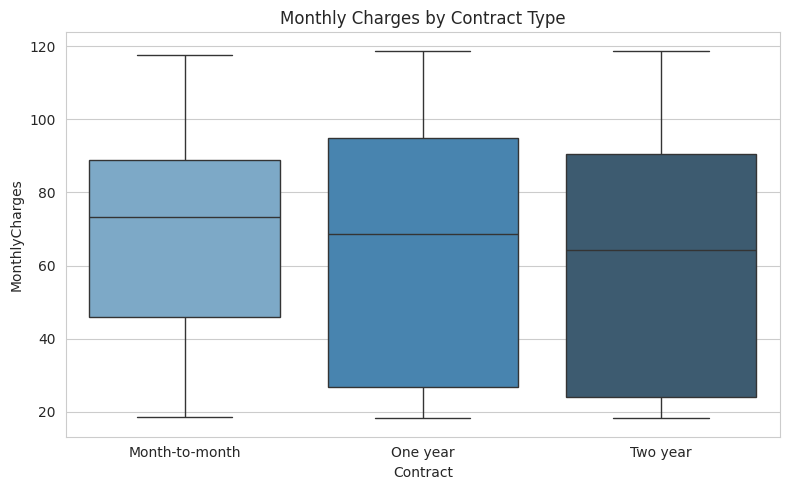

                 mean  median
Contract                     
Month-to-month  66.40   73.25
One year        65.05   68.75
Two year        60.77   64.35


In [3]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Contract', y='MonthlyCharges',
            order=['Month-to-month', 'One year', 'Two year'],
            hue='Contract', palette='Blues_d', legend=False)
plt.title('Monthly Charges by Contract Type')
plt.tight_layout()
plt.show()

print(df.groupby('Contract')['MonthlyCharges'].agg(['mean', 'median']).round(2))


### Interpretation
Month-to-month customers pay a modestly higher median (\$73.25) than Two year customers
(\$64.35) — a real but not dramatic difference, and nowhere near as stark as the churn
rate difference between these same two groups (Notebook 5: 42.7% vs 2.8%).

### Insight
This is an important negative-ish finding: `Contract`'s overwhelming relationship with
churn is **not** simply because month-to-month customers pay drastically more — the price
gap is modest. This reinforces that contract *commitment* itself (not primarily price) is
the mechanism driving the churn difference.

### Insight Obtained
This strengthens the case (first raised in Notebook 6) that `Contract` carries
independent predictive value beyond what `MonthlyCharges` alone would suggest — an
important distinction for feature importance interpretation in the next sprint.


---
## 3. Bar Chart — Average `TotalCharges` by `InternetService`

### Why This Visualization Was Selected
Notebook 9's bar charts showed category *counts*; this bar chart instead aggregates a
numeric value (mean `TotalCharges`) per category — a genuinely different, business-value
question: "which internet service type generates the most customer lifetime billing?"

### Implementation


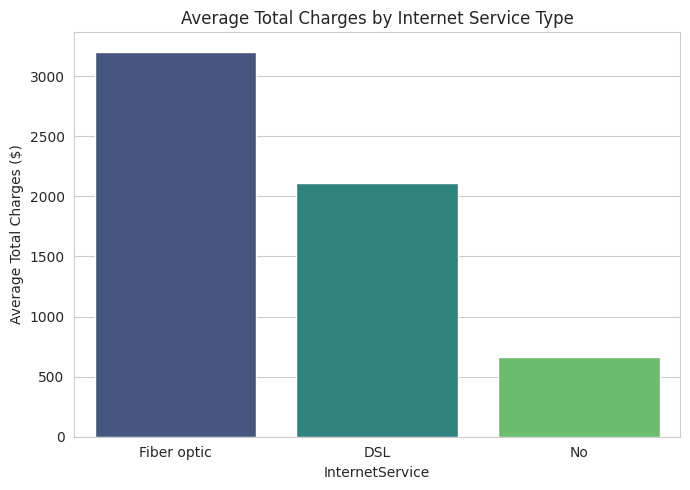

InternetService
Fiber optic    3205.30
DSL            2115.41
No              662.60
Name: TotalCharges, dtype: float64


In [4]:
avg_total_by_internet = df.groupby('InternetService')['TotalCharges'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=avg_total_by_internet.index, y=avg_total_by_internet.values,
            hue=avg_total_by_internet.index, palette='viridis', legend=False)
plt.title('Average Total Charges by Internet Service Type')
plt.ylabel('Average Total Charges ($)')
plt.tight_layout()
plt.show()

print(avg_total_by_internet.round(2))


### Interpretation
Fiber optic customers have accumulated the highest average `TotalCharges` (\$3,205),
about 50% more than DSL customers (\$2,115), and nearly 5x customers with no internet
service (\$663).

### Insight
Fiber optic is simultaneously this dataset's highest-churn internet service (Notebook 5:
41.9% churn) AND its highest-lifetime-value segment — meaning fiber customer churn isn't
just a volume problem, it's a **disproportionately costly** one in terms of lost revenue
per lost customer.

### Insight Obtained
This directly sharpens the business priority already suggested by Notebooks 5-6: retention
efforts aimed at fiber optic customers deserve outsized priority, since each fiber
customer lost represents more accumulated revenue than a DSL or no-internet customer lost.


---
## 4. Count Plot — `Dependents` Split by `Churn`

### Why This Visualization Was Selected
Notebook 9's systematic scan found `Dependents` has a real (15.8-point) churn-rate
spread, but it was never visualized directly — worth a dedicated look since it's a
demographic factor distinct from the service/contract factors already visualized
extensively.

### Implementation


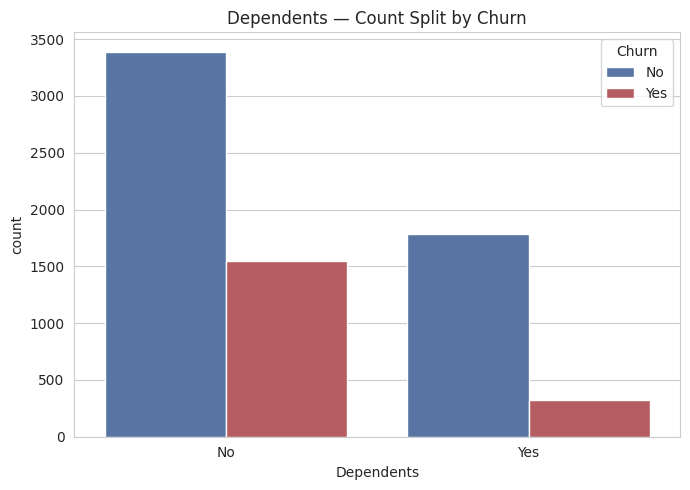

Churn         No   Yes
Dependents            
No          3390  1543
Yes         1784   326


In [5]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Dependents', hue='Churn', order=['No', 'Yes'],
              palette={'No': '#4C72B0', 'Yes': '#C44E52'})
plt.title('Dependents — Count Split by Churn')
plt.tight_layout()
plt.show()

print(pd.crosstab(df['Dependents'], df['Churn']))


### Interpretation
Customers without dependents (3,390 stayed, 1,543 churned) make up the clear majority of
both the customer base and the churned population, but the *rate* is what matters more
than the raw counts: customers WITH dependents churn notably less often proportionally
(only 326 out of 2,110, about 15.5%) than those without (1,543 out of 4,933, about
31.3%).

### Insight
A count plot alone (raw bars) would make it look like "customers without dependents are
the churn problem" simply because they're the larger group — but the *rate* comparison
(already established in Notebook 9) shows the real story is about proportion, not volume.
This is a useful teaching moment about reading count plots carefully alongside rate-based
crosstabs, not in place of them.

### Insight Obtained
Having dependents appears to correlate with household stability that extends to reduced
churn — worth testing alongside `Partner` (a related, similarly-behaving feature per
Notebook 9) as a combined "household stability" signal in future feature engineering.


---
## 5. Scatter Plot — `MonthlyCharges` vs `TotalCharges`, Colored by `tenure`

### Why This Visualization Was Selected
Notebook 6 plotted this same pair colored by `Churn`. Recoloring by `tenure` (a continuous
variable, using a color gradient rather than discrete categories) answers a different
question: does the curved relationship seen in Notebook 6 have a clean, continuous
explanation in tenure?

### Implementation


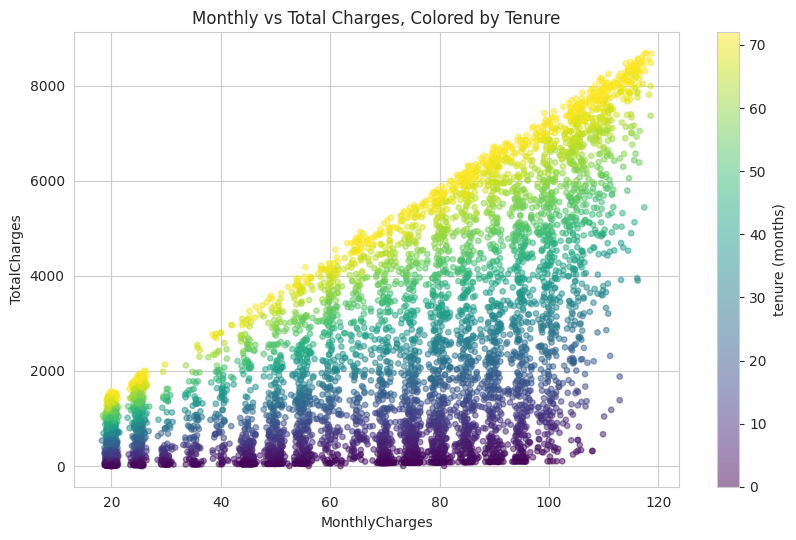

In [6]:
plt.figure(figsize=(8.5, 5.5))
scatter = plt.scatter(df['MonthlyCharges'], df['TotalCharges'], c=df['tenure'],
                       cmap='viridis', alpha=0.5, s=15)
plt.colorbar(scatter, label='tenure (months)')
plt.xlabel('MonthlyCharges')
plt.ylabel('TotalCharges')
plt.title('Monthly vs Total Charges, Colored by Tenure')
plt.tight_layout()
plt.show()


### Interpretation
The color gradient explains the curved scatter shape completely: dark (low-tenure)
points hug the bottom regardless of `MonthlyCharges`, while bright (high-tenure) points
rise to the top — confirming visually that `TotalCharges`'s spread is almost entirely
explained by the combination of `MonthlyCharges` and `tenure` together, exactly as the
multiplicative relationship (Notebook 6-7) would predict.

### Insight
This is a clean visual confirmation of Notebook 6's numeric finding (`TotalCharges` VIF
≈ 8.1) — there is no "hidden" third factor needed to explain `TotalCharges`'s
variation; tenure and monthly rate together are essentially sufficient.

### Insight Obtained
This further reinforces the Notebook 6 recommendation: `TotalCharges` can likely be
dropped from a linear model in favor of `tenure` and `MonthlyCharges`, since this chart
shows visually — not just numerically — how little independent information it adds.


---
## 6. Line Plot — Churn Rate by Tenure Month (the "Retention Curve")

### Why This Visualization Was Selected
A line plot is the right chart for a value that changes across an ordered sequence
(Sprint 2, Notebook 13) — here, tenure month by tenure month. This is a **new analysis**,
not previously performed in this sprint: rather than treating `tenure` as a single
distribution or box-plot comparison, this tracks the churn RATE at every individual
tenure value, revealing the shape of customer retention over time.

### Implementation


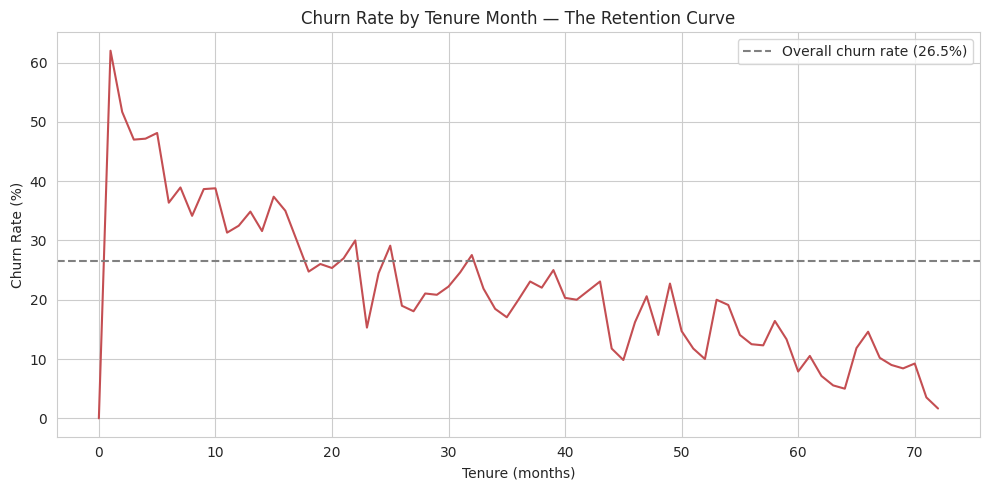

In [7]:
churn_rate_by_tenure = df.groupby('tenure')['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)

plt.figure(figsize=(10, 5))
plt.plot(churn_rate_by_tenure.index, churn_rate_by_tenure.values, color='#C44E52', linewidth=1.5)
plt.axhline(df['Churn'].eq('Yes').mean() * 100, color='gray', linestyle='--',
            label=f"Overall churn rate ({df['Churn'].eq('Yes').mean()*100:.1f}%)")
plt.xlabel('Tenure (months)')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Tenure Month — The Retention Curve')
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation
The curve is dramatic: churn rate starts at **62% for 1-month customers**, and falls
sharply and almost continuously as tenure increases, dropping to single digits by around
month 60+ and reaching as low as 1.7% at month 72. This is a classic "early cliff, long
tail" retention curve.

### Insight
This is the single most visually striking finding in this entire sprint, and it sharpens
every earlier tenure-related finding into a specific, actionable number: **the first few
months of a customer's tenure are where the overwhelming majority of churn risk is
concentrated**, not spread evenly across the customer lifecycle.

### Insight Obtained
This chart alone justifies a specific business recommendation for Notebook 12: retention
efforts should be front-loaded into a customer's first 1-3 months, since that's where the
retention curve is steepest — a far more precise and actionable insight than "shorter
tenure correlates with churn" (Notebook 5's original finding).


---
## 7. Violin Plot — `TotalCharges` by `Churn`

### Why This Visualization Was Selected
Notebook 5 used a violin plot for `MonthlyCharges` by `Churn`; `TotalCharges` was only
ever compared with a scatter plot (Notebook 6), never a violin. Given `TotalCharges`'s
pronounced skew (Notebook 8), a violin plot is a good test of whether that skew looks
different across the two churn groups.

### Implementation


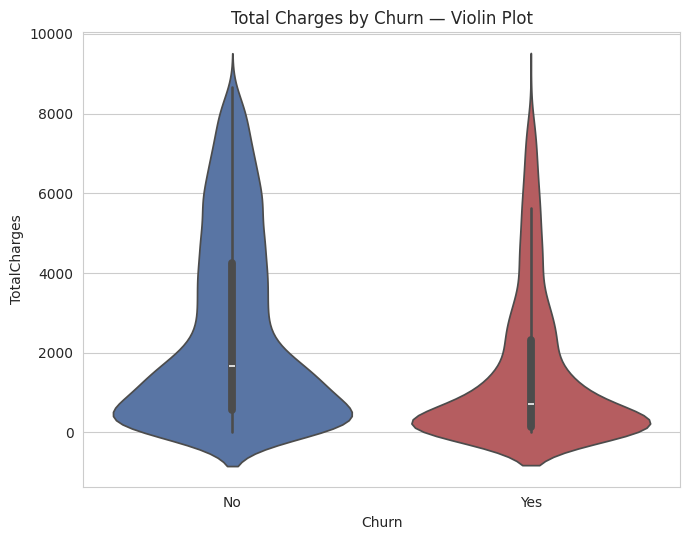

          mean   median
Churn                  
No     2549.91  1679.52
Yes    1531.80   703.55


In [8]:
plt.figure(figsize=(7, 5.5))
sns.violinplot(data=df, x='Churn', y='TotalCharges', order=['No', 'Yes'],
               hue='Churn', palette={'No': '#4C72B0', 'Yes': '#C44E52'}, legend=False)
plt.title('Total Charges by Churn — Violin Plot')
plt.tight_layout()
plt.show()

print(df.groupby('Churn')['TotalCharges'].agg(['mean', 'median']).round(2))


### Interpretation
The churned group's violin is dramatically compressed toward the bottom (low
`TotalCharges`), while the non-churned group's violin is much wider and taller, extending
well into the high-value range. The churned group's median (\$703.55) is well under half
of the non-churned group's median (\$1,679.52) — a substantial, but not quite
five-fold, gap.

### Insight
This isn't simply restating "churners have less tenure" (already known) — the violin's
shape shows churned customers' `TotalCharges` distribution is itself heavily
concentrated near zero, meaning most churn happens before a customer accumulates
meaningful lifetime value at all.

### Insight Obtained
Combined with the retention curve (Topic 6), this reinforces that most churned customers
represent limited realized revenue loss individually, but their sheer volume (1,869
customers) in the earliest, most vulnerable tenure window makes early retention the
highest-leverage intervention point.


---
## 8. Pair Plot — Numeric Features Colored by `Contract` (Instead of `Churn`)

### Why This Visualization Was Selected
Notebook 6's pair plot was colored by `Churn`. Recoloring the same grid by `Contract`
instead tests a different question: do the three contract types occupy visually distinct
regions of the numeric feature space, independent of churn status?

### Implementation


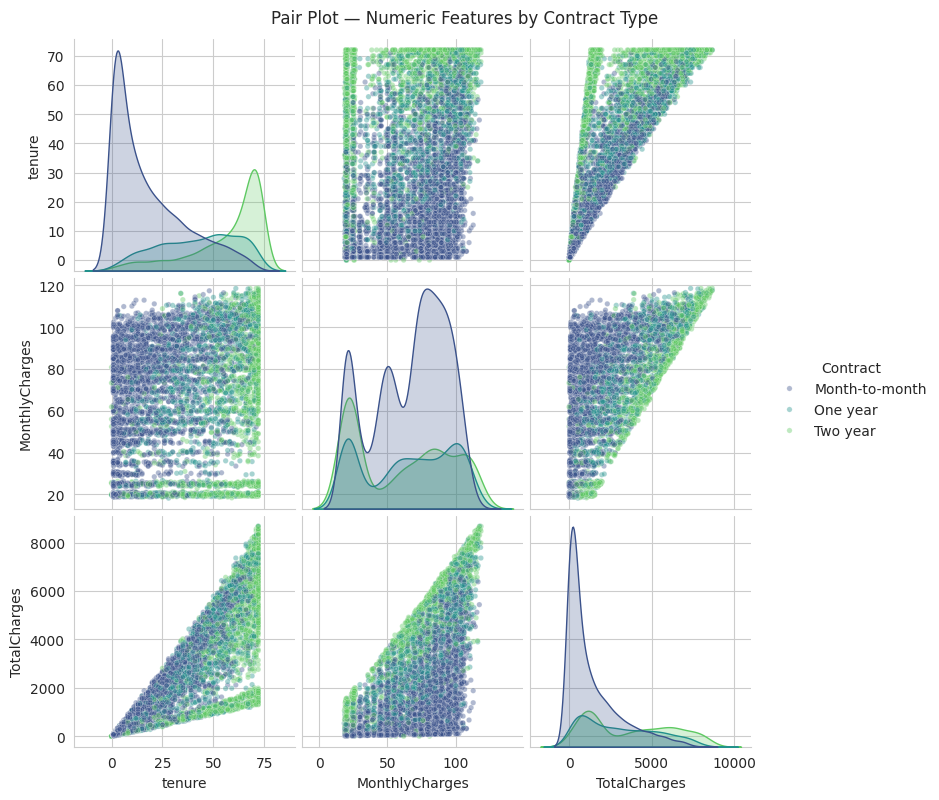

In [9]:
pairplot_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract']
sns.pairplot(df[pairplot_cols], hue='Contract',
             hue_order=['Month-to-month', 'One year', 'Two year'],
             palette='viridis', plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde', height=2.6)
plt.suptitle('Pair Plot — Numeric Features by Contract Type', y=1.02)
plt.show()


### Interpretation
Unlike the `Churn`-colored version (Notebook 6), where classes overlapped heavily, the
`Contract`-colored version shows much cleaner separation along the `tenure` axis
specifically — Two year contracts (one color) visibly cluster toward high tenure, while
Month-to-month clusters toward low-to-mid tenure, consistent with Notebook 5's finding
that tenure rises with contract length.

### Insight
`Contract` separates more cleanly across these numeric features than `Churn` does — which
makes sense, since `Contract` is more directly, mechanically related to `tenure` (a
customer must survive to renew into a longer contract) than `Churn` is to any single
numeric feature.

### Insight Obtained
This is a useful modeling signal: `Contract` may be an easier target to predict from
numeric features alone than `Churn` is — reinforcing that churn prediction genuinely
needs the categorical service/contract features, not just the three numeric columns, to
perform well.


---
## 9. Heatmap — Churn Rate Across `Contract` x `InternetService` (Not a Correlation Matrix)

### Why This Visualization Was Selected
Notebook 6's heatmap visualized a correlation matrix. This heatmap instead visualizes an
**aggregated churn rate** across a 2-dimensional category grid — testing Notebook 6's
open finding (that `InternetService`'s effect holds within price bands) from a different,
more direct angle: does it also hold within each contract type?

### Implementation


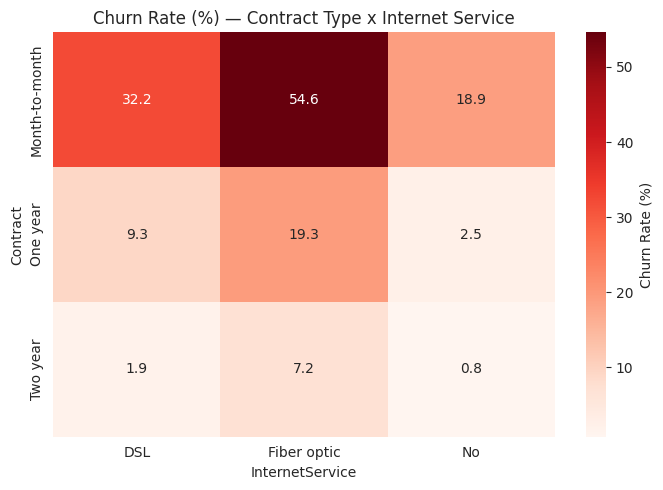

In [10]:
churn_rate_grid = df.pivot_table(index='Contract', columns='InternetService',
                                   values='Churn', aggfunc=lambda s: (s == 'Yes').mean() * 100)
churn_rate_grid = churn_rate_grid.reindex(['Month-to-month', 'One year', 'Two year'])

plt.figure(figsize=(7, 5))
sns.heatmap(churn_rate_grid, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%) — Contract Type x Internet Service')
plt.tight_layout()
plt.show()


### Interpretation
The single highest-risk combination is unambiguous: **Month-to-month + Fiber optic
churns at 54.6%** — more than half of these customers leave. The single lowest-risk
combination is **Two year + No internet service at 0.8%**. Critically, Fiber optic shows
the highest churn rate within EVERY contract length (54.6% / 19.3% / 7.2%), confirming
Notebook 6's finding held up from yet another angle.

### Insight
This heatmap identifies a specific, extreme-risk customer segment
(Month-to-month + Fiber optic) that neither `Contract` nor `InternetService` alone fully
captures — over half of this exact combination churns, a rate far higher than either
factor's individual churn rate would suggest in isolation.

### Insight Obtained
This is this sprint's single most actionable targeting insight: a retention campaign
specifically aimed at Month-to-month, Fiber optic customers would concentrate effort on
the highest-risk, highest-value (Topic 3) segment simultaneously.


---
## 10. Distribution Plot — `MonthlyCharges` Density, Split by `Churn`

### Why This Visualization Was Selected
A KDE-based distribution plot overlaying both churn groups on the same axis directly
tests whether the two groups' `MonthlyCharges` distributions are meaningfully separated —
a sharper visual than the box plot already used in Notebook 5 for the same variable.

### Implementation


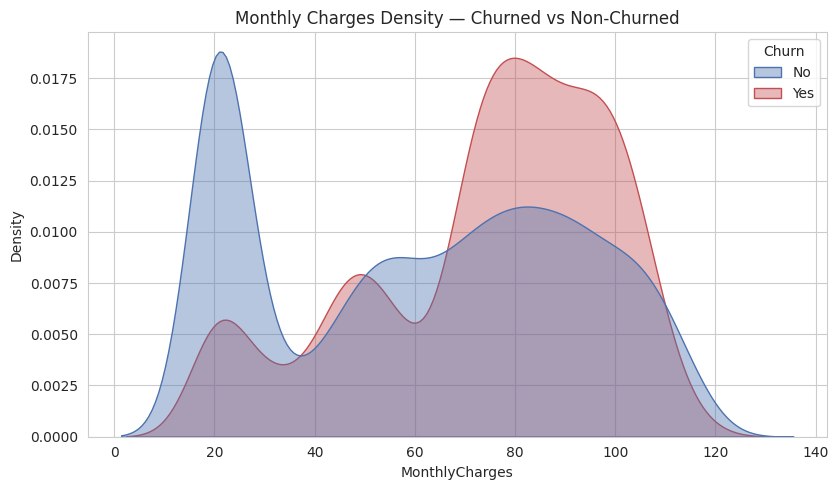

In [11]:
plt.figure(figsize=(8.5, 5))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False,
            palette={'No': '#4C72B0', 'Yes': '#C44E52'}, alpha=0.4)
plt.title('Monthly Charges Density — Churned vs Non-Churned')
plt.tight_layout()
plt.show()


### Interpretation
The non-churned group's density shows a strong peak around \$20 (a large cluster of
low-cost, likely phone-only customers) plus a broader hump at higher prices. The churned
group's density is much more concentrated in the \$70-100 range, with almost none of the
low-cost peak the non-churned group shows.

### Insight
This visually confirms and sharpens Notebook 5's finding (churners pay more on average)
— it's not just a shifted average, it's a genuinely different distribution *shape*: the
non-churned group includes a large low-cost segment almost entirely absent from the
churned group.

### Insight Obtained
This suggests low-cost (likely phone-only, no-internet) customers are this dataset's most
loyal segment by a wide margin — a positive finding worth including in Notebook 12
alongside the risk-focused findings, since it identifies a segment that *doesn't* need
retention intervention.


---
## Summary

| # | Visualization | New Question Asked | Key Insight |
|---|---|---|---|
| 1 | Histogram | Does log-transforming TotalCharges actually fix its skew? | Overcorrects to left-skew due to 11 zero-charge new customers |
| 2 | Box Plot | Does MonthlyCharges differ by Contract? | Only modestly — Contract's churn link isn't primarily about price |
| 3 | Bar Chart | Which InternetService generates the most lifetime billing? | Fiber optic: highest value AND highest churn — a costly combination |
| 4 | Count Plot | How does Dependents split by Churn? | Raw counts mislead; rate (Notebook 9) tells the real story |
| 5 | Scatter Plot | Does tenure explain the MonthlyCharges/TotalCharges curve? | Yes, visually confirms the VIF~8.1 multicollinearity finding |
| 6 | Line Plot | What does the retention curve look like month-by-month? | 62% churn at month 1, falling to ~2-9% by month 60+ |
| 7 | Violin Plot | Does TotalCharges's skew differ by Churn group? | Churned group heavily concentrated near zero value |
| 8 | Pair Plot | Does Contract separate more cleanly than Churn? | Yes — Contract is more mechanically tied to tenure |
| 9 | Heatmap | Which Contract x InternetService combo is highest risk? | Month-to-month + Fiber optic: 54.6% churn |
| 10 | Distribution Plot | Do MonthlyCharges distributions differ by shape, not just average? | Non-churned group has a large low-cost loyal segment churners lack |

**Next notebook:** `12_Business_Insights.ipynb` — converting every finding from
Notebooks 1-11 into concrete business observations, patterns, and opportunities.
